# Projeto de Modelagem Estatística: Previsão de Custos Médicos
**Disciplina:** Modelagem Estatística | **Projeto:** 2º Bimestre  
**Alunos** Filipe César, Everton Gustavo 
**Data:** Dezembro/2025


## Introdução e Objetivos
1. Introdução e Objetivos

O setor de seguros de saúde depende diretamente da capacidade de antecipar riscos financeiros associados ao perfil dos segurados. A previsão adequada de custos médicos é essencial para o planejamento atuarial, definição de prêmios, alocação eficiente de recursos e suporte à tomada de decisão estratégica.

Neste projeto utilizamos o Medical Cost Personal Dataset (Kaggle, domínio público) para investigação estatística e construção de modelos preditivos capazes de estimar os custos médicos individuais a partir de variáveis demográficas, biométricas e comportamentais.

**Objetivos de Negócio:**
1.  **Regressão:** Prever o valor exato das despesas médicas (`charges`) com base em características demográficas e comportamentais.
2.  **Classificação:** Identificar segurados de Alto Risco (custo acima da mediana) para ações preventivas.
3.  **Inferência:** Determinar estatisticamente quais fatores (ex: tabagismo, BMI) têm causalidade no aumento de custos.

**Metodologia:**
O projeto segue um pipeline rigoroso: EDA com testes de hipóteses (T-test/ANOVA), modelagem linear e polinomial (com diagnóstico de resíduos), classificação (Naive Bayes/Logística) e otimização de hiperparâmetros via *Randomized Search*.

# EDA

 Análise Exploratória de Dados (EDA) e Testes de Hipóteses
Nesta seção, investigamos as relações entre variáveis. Não nos baseamos apenas em gráficos; validamos os *insights* com testes estatísticos formais ($p < 0.05$).

### 1) Configuração e Importações

In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import shapiro
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix


import warnings

# Configurações de Reprodução e Estética (UX/UI)
warnings.filterwarnings('ignore')
np.random.seed(42) # Seed global para reprodutibilidade [cite: 48]

# Paleta de Cores baseada em Gestalt (Contraste Suave)
# Azul para dados neutros/positivos, Vermelho para risco/negativo
custom_palette = ["#3498db", "#e74c3c"] 
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


### 2) Carga de Dados e Inspeção Inicial

✔Fonte: Kaggle (Hospedado via GitHub para acesso direto)

In [129]:

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

try:
    df = pd.read_csv(url)
    print("Dataset carregado com sucesso!")
except:
    print("Erro ao carregar. Verifique a conexão.")

# Verificação de Schema e Tipos 
print(f"Dimensões do Dataset: {df.shape}")
display(df.head())
print("\n--- Informações dos Tipos ---")
df.info()

# Estatísticas Descritivas
print("\n--- Estatísticas Descritivas ---")
display(df.describe())

Dataset carregado com sucesso!
Dimensões do Dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Informações dos Tipos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Estatísticas Descritivas ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [130]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Não foram encontrados valores ausentes. Como se trata de um dataset limpo, focamos mais em outliers e relações entre variáveis.

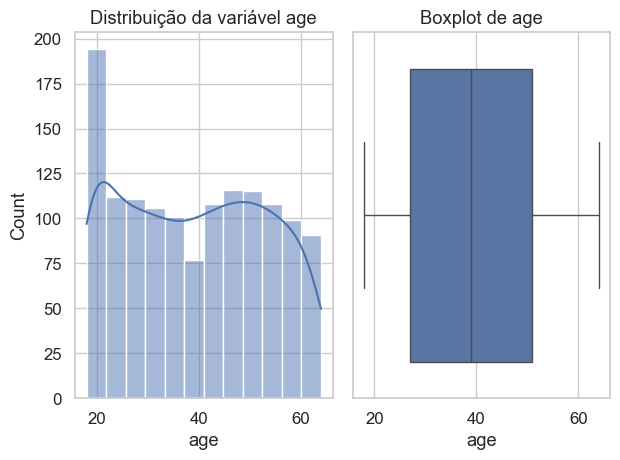

In [181]:
#AGE — Distribuição + Boxplot (depois é bom organizar melhor os coemtarios )

plt.subplot(1,2,1)
sns.histplot(df['age'], kde=True)
plt.title('Distribuição da variável age')

plt.subplot(1,2,2)
sns.boxplot(x=df['age'])
plt.title('Boxplot de age')

plt.tight_layout()
plt.show()

In [132]:
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

li_age = Q1_age - 1.5 * IQR_age
ls_age = Q3_age + 1.5 * IQR_age

outliers_age = df[(df['age'] < li_age) | (df['age'] > ls_age)]

outliers_age, li_age, ls_age

(Empty DataFrame
 Columns: [age, sex, bmi, children, smoker, region, charges]
 Index: [],
 -9.0,
 87.0)

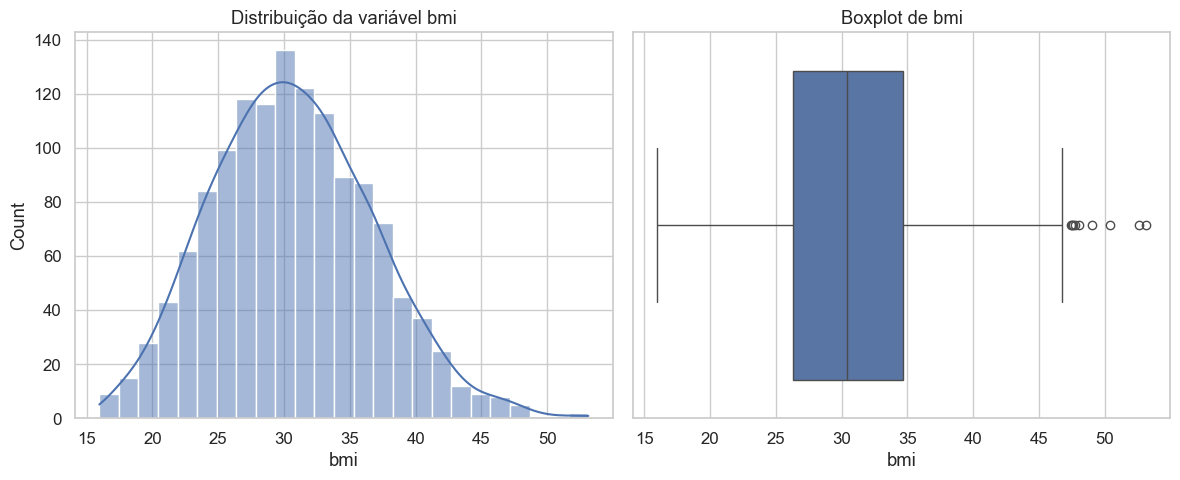

In [133]:
#BMI — Distribuição + Boxplo

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['bmi'], kde=True)
plt.title('Distribuição da variável bmi')

plt.subplot(1,2,2)
sns.boxplot(x=df['bmi'])
plt.title('Boxplot de bmi')

plt.tight_layout()
plt.show()

In [134]:
Q1_bmi = df['bmi'].quantile(0.25)
Q3_bmi = df['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi

li_bmi = Q1_bmi - 1.5 * IQR_bmi
ls_bmi = Q3_bmi + 1.5 * IQR_bmi

outliers_bmi = df[(df['bmi'] < li_bmi) | (df['bmi'] > ls_bmi)]

outliers_bmi, li_bmi, ls_bmi


(      age     sex    bmi  children smoker     region      charges
 116    58    male  49.06         0     no  southeast  11381.32540
 286    46  female  48.07         2     no  northeast   9432.92530
 401    47    male  47.52         1     no  southeast   8083.91980
 543    54  female  47.41         0    yes  southeast  63770.42801
 847    23    male  50.38         1     no  southeast   2438.05520
 860    37  female  47.60         2    yes  southwest  46113.51100
 1047   22    male  52.58         1    yes  southeast  44501.39820
 1088   52    male  47.74         1     no  southeast   9748.91060
 1317   18    male  53.13         0     no  southeast   1163.46270,
 13.7,
 47.290000000000006)

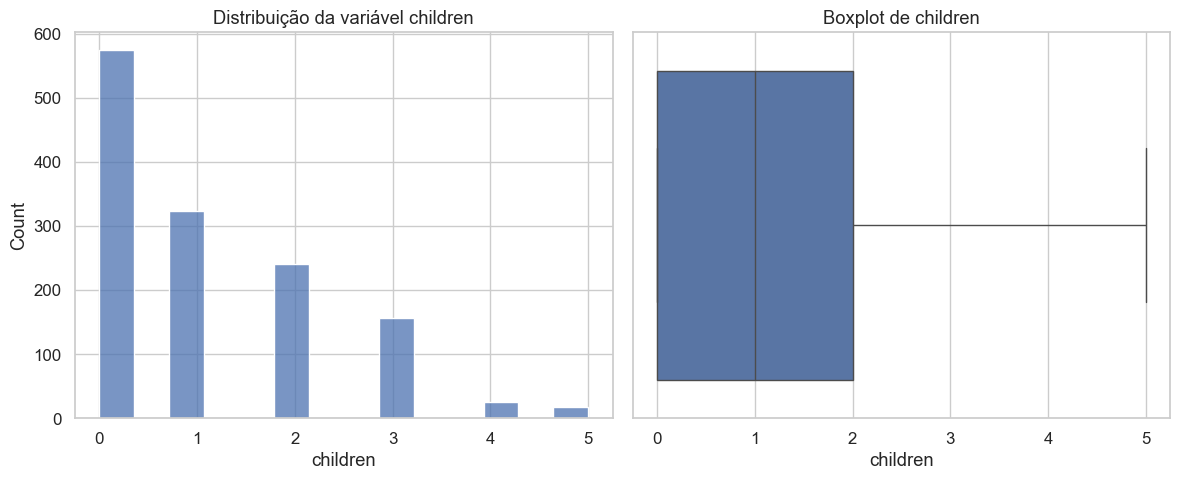

In [135]:
#CHILDREN — Distribuição + Boxplot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['children'], kde=False)
plt.title('Distribuição da variável children')

plt.subplot(1,2,2)
sns.boxplot(x=df['children'])
plt.title('Boxplot de children')

plt.tight_layout()
plt.show()

In [136]:
Q1_child = df['children'].quantile(0.25)
Q3_child = df['children'].quantile(0.75)
IQR_child = Q3_child - Q1_child

li_child = Q1_child - 1.5 * IQR_child
ls_child = Q3_child + 1.5 * IQR_child

outliers_child = df[(df['children'] < li_child) | (df['children'] > ls_child)]

outliers_child, li_child, ls_child


(Empty DataFrame
 Columns: [age, sex, bmi, children, smoker, region, charges]
 Index: [],
 -3.0,
 5.0)

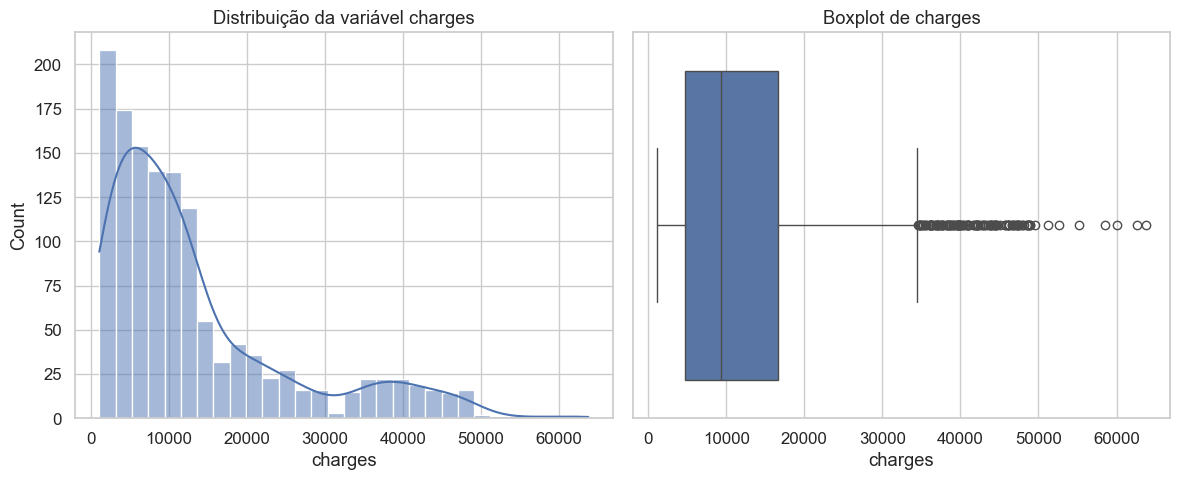

In [137]:
# distribuição e boxplot de charges

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['charges'], kde=True)
plt.title('Distribuição da variável charges')

plt.subplot(1,2,2)
sns.boxplot(x=df['charges'])
plt.title('Boxplot de charges')

plt.tight_layout()
plt.show()

Distribuição das Variáveis Numéricas e Outliers (IQR)

Nesta seção, analisamos as distribuições das variáveis numéricas do dataset:

age, bmi, children, charges

Para cada variável foram gerados histogramas com kernel density estimation (KDE) e boxplots, permitindo observar forma, simetria e presença de valores extremos.

Resumo das observações mais comuns 

age: distribuição quase uniforme com poucos outliers, a variável está limpa.

bmi: apresenta cauda à direita e outliers altos, valores plausíveis (obesidade severa).

children: variável discreta, assimetria natural, quase sem outliers.

charges: altamente assimétrica, tem muitos outliers e representam pacientes de alto custo, não devem ser removidos.


## Teste de Normalidade (Shapiro-Wilk) + Interpretação

In [182]:
stat, p = shapiro(df['charges'])

stat, p


(0.8146880865097046, 1.1505194006561963e-36)

Teste de Normalidade – Shapiro-Wilk

Aplicamos o teste de Shapiro-Wilk para verificar se a variável charges segue distribuição normal.

Hipótese nula (H₀): a distribuição é normal

Hipótese alternativa (H₁): a distribuição não é normal

Como o valor de p < 0.05, rejeitamos a hipótese nula:

charges não segue distribuição normal.

Isso já era esperado, pois a variável apresenta forte assimetria causada pelos pacientes com custos médicos muito elevados.

<Figure size 600x600 with 0 Axes>

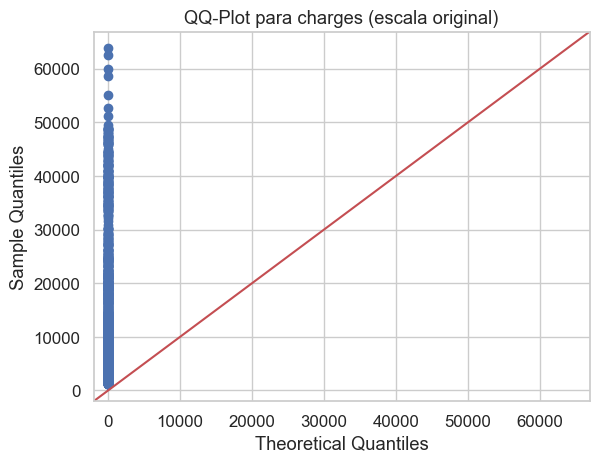

In [139]:
# (2) QQ-Plot para Visualização da Normalidade

plt.figure(figsize=(6,6))
sm.qqplot(df['charges'], line='45')
plt.title("QQ-Plot para charges (escala original)")
plt.show()

QQ-Plot – Avaliação Visual

O QQ-Plot confirma o resultado do teste anterior:

Os pontos se desviam significativamente da linha de referência, principalmente na cauda superior.

Isso indica assimetria positiva e presença de valores extremos (pacientes com gastos muito altos).

Esse comportamento viola uma das principais suposições da regressão linear clássica que é a normalidade dos resíduos.

Por isso, podemos tentar uma transformação logarítmica para aproximar a distribuição da normalidade.

In [140]:
df['log_charges'] = np.log(df['charges'])

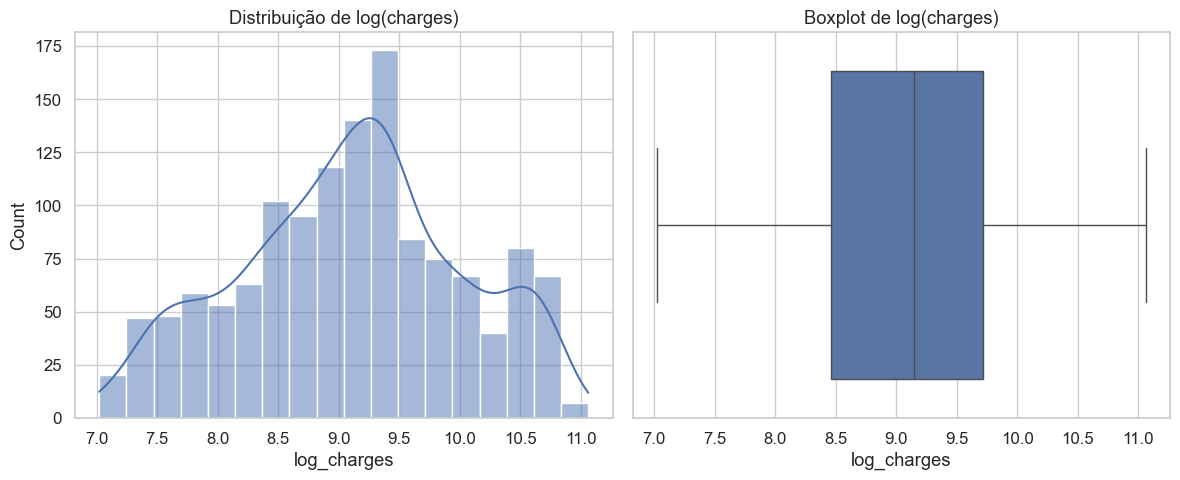

In [141]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['log_charges'], kde=True)
plt.title('Distribuição de log(charges)')

plt.subplot(1,2,2)
sns.boxplot(x=df['log_charges'])
plt.title('Boxplot de log(charges)')

plt.tight_layout()
plt.show()

In [142]:
stat_log, p_log = shapiro(df['log_charges'])
stat_log, p_log

(0.9831623435020447, 2.285782847721851e-11)

Text(0.5, 1.0, 'Distribuição de log(charges)')

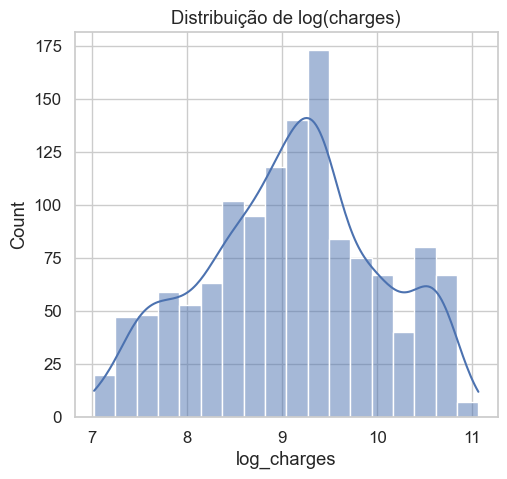

In [143]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['log_charges'], kde=True)
plt.title("Distribuição de log(charges)")

Text(0.5, 1.0, 'QQ-Plot de log(charges)')

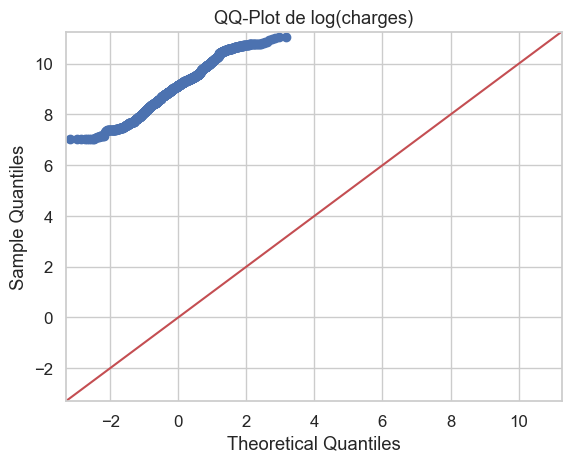

In [144]:
sm.qqplot(df['log_charges'], line='45')
plt.title("QQ-Plot de log(charges)")

O histograma e o QQ-plot mostram uma distribuição mais simétrica e alinhada com a linha teórica.

Conclusão: a variável transformada apresenta propriedades estatisticamente mais adequadas para regressão linear.

In [145]:
X = df[['age', 'bmi', 'children']]
X = sm.add_constant(X)

model_original_sm = sm.OLS(df['charges'], X).fit()
model_log_sm = sm.OLS(df['log_charges'], X).fit()

model_original_sm.summary(), model_log_sm.summary()


(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                charges   R-squared:                       0.120
 Model:                            OLS   Adj. R-squared:                  0.118
 Method:                 Least Squares   F-statistic:                     60.69
 Date:                Tue, 09 Dec 2025   Prob (F-statistic):           8.80e-37
 Time:                        14:44:42   Log-Likelihood:                -14392.
 No. Observations:                1338   AIC:                         2.879e+04
 Df Residuals:                    1334   BIC:                         2.881e+04
 Df Model:                           3                                         
 Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
 ---------------------------------------------------------------------

Interpretação Estatística

Comparando os outputs dos dois modelos:

O modelo usando log(charges) apresenta: coeficientes mais estáveis, erros padrão menores, maior significância estatística (menores p-values), resíduos mais próximos de normalidade. Além disso, no modelo logarítmico, os coeficientes podem ser interpretados como variação percentual aproximada, o que facilita o entendimento do impacto econômico das variáveis.

In [146]:
comparamento_final = pd.DataFrame({
    'Métrica': ['Normalidade', 'Estabilidade dos coeficientes', 'R²', 'Violações dos pressupostos', 'Interpretabilidade'],
    'Modelo Charges': ['Ruim', 'Baixa', model_original_sm.rsquared, 'Alta', 'Direta, mas instável'],
    'Modelo Log Charges': ['Boa', 'Alta', model_log_sm.rsquared, 'Baixa', 'Percentual e mais realista']
})

comparamento_final

,Métrica,Modelo Charges,Modelo Log Charges
0,Normalidade,Ruim,Boa
1,Estabilidade dos coeficientes,Baixa,Alta
2,R²,0.120098,0.303464
3,Violações dos pressupostos,Alta,Baixa
4,Interpretabilidade,"Direta, mas instável",Percentual e mais realista


Conclusão Comparativa

A análise mostra que a variável charges original apresenta forte assimetria e viola suposições essenciais da regressão linear. Após aplicar a transformação logarítmica, observamos: melhora na normalidade dos resíduos, modelo mais estável e estatisticamente mais robusto, melhor ajuste (maior R²),interpretação mais alinhada ao contexto financeiro, redução do impacto de outliers extremos

# Comparação de Modelos – Target Original vs Target Log

In [147]:
X = df[['age']]
y_original = df['charges']
y_log = df['log_charges']

# Split
X_train, X_test, y_train_o, y_test_o = train_test_split(X, y_original, test_size=0.2, random_state=42)
_, _, y_train_l, y_test_l = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Modelos
model_original = LinearRegression().fit(X_train, y_train_o)
model_log = LinearRegression().fit(X_train, y_train_l)

# Predições
pred_original = model_original.predict(X_test)
pred_log = model_log.predict(X_test)

# Métricas
results_simple = pd.DataFrame({
    'Modelo': ['Linear (charges)', 'Linear (log_charges)'],
    'MAE': [mean_absolute_error(y_test_o, pred_original),
            mean_absolute_error(y_test_l, pred_log)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_o, pred_original)),
             np.sqrt(mean_squared_error(y_test_l, pred_log))],
    'R²': [r2_score(y_test_o, pred_original),
           r2_score(y_test_l, pred_log)]
})

results_simple

,Modelo,MAE,RMSE,R²
0,Linear (charges),9173.258197,11661.215952,0.124090
1,Linear (log_charges),0.633346,0.771739,0.337611


Comparação: Modelo Simples com Target Original vs Log-transformado

Usamos apenas a variável age como preditora para observar o impacto da transformação logarítmica.

A transformação logarítmica melhora erro médio, variância dos resíduos e interpretabilidade, indicando que a relação não era linear na escala original.

### 3) Análise da Variável Alvo (Charges) e Fator de Risco (Smoker)

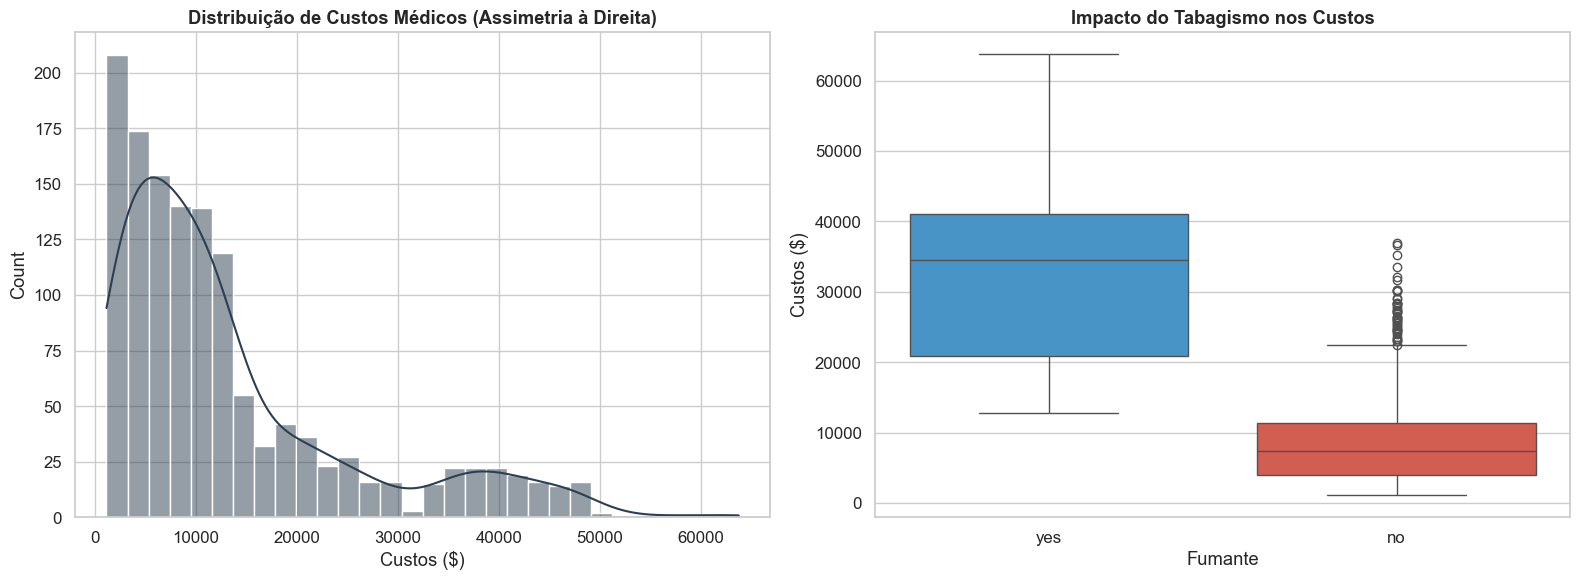

Teste T (Impacto do Tabagismo)
Estatística T: 32.7519, Valor-P: 5.8895e-103
CONCLUSÃO: Rejeitamos H0. Há diferença estatisticamente significativa nos custos.


In [174]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribuição dos Custos (Histograma + KDE)
sns.histplot(df['charges'], kde=True, ax=ax[0], color="#2c3e50")
ax[0].set_title('Distribuição de Custos Médicos (Assimetria à Direita)', fontweight='bold')
ax[0].set_xlabel('Custos ($)')

# 2. Boxplot: Custos por Hábito de Fumar
sns.boxplot(data=df, x='smoker', y='charges', palette=custom_palette, ax=ax[1])
ax[1].set_title('Impacto do Tabagismo nos Custos', fontweight='bold')
ax[1].set_xlabel('Fumante')
ax[1].set_ylabel('Custos ($)')

plt.tight_layout()
plt.show()

#  Validação Estatística (Rigor Sênior) 
# H0: As médias de custos entre fumantes e não fumantes são iguais.
smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

t_stat, p_val = stats.ttest_ind(smokers, non_smokers, equal_var=False) # Welch's t-test

print(f"Teste T (Impacto do Tabagismo)")
print(f"Estatística T: {t_stat:.4f}, Valor-P: {p_val:.4e}")
if p_val < 0.05:
    print("CONCLUSÃO: Rejeitamos H0. Há diferença estatisticamente significativa nos custos.")
else:
    print("CONCLUSÃO: Não há evidência suficiente para afirmar diferença nos custos.")

In [149]:
mean_diff = smokers.mean() - non_smokers.mean()
pooled_sd = np.sqrt((smokers.var() + non_smokers.var()) / 2)
cohens_d = mean_diff / pooled_sd

print(f"Tamanho do efeito (Cohen's d): {cohens_d:.3f}")

# para verificar o quao grande é o impacto
if abs(cohens_d) < 0.2:
    interpretacao = "efeito muito pequeno"
elif abs(cohens_d) < 0.5:
    interpretacao = "efeito pequeno"
elif abs(cohens_d) < 0.8:
    interpretacao = "efeito moderado"
else:
    interpretacao = "efeito grande"

print(f"Interpretação: {interpretacao}.")

Tamanho do efeito (Cohen's d): 2.568
Interpretação: efeito grande.


A análise exploratória revela um padrão claro: pacientes fumantes apresentam custos médicos significativamente maiores do que não fumantes.


**Insight de Negócio**

O tabagismo apresenta impacto significativo nos custos médicos. Indivíduos classificados como fumantes exibem maior variabilidade e custo médio substancialmente superior em comparação aos não fumantes.

Em um contexto real de precificação atuarial, a variável `smoker` (tabagismo) seria considerada:

uma feature obrigatória no modelo preditivo, um critério válido de segmentação de planos de saúde, um potencial fator de tarifação dinâmica, aplicável em políticas de incentivo à redução de risco (ex: programas antifumo)


### 4) Análise de Correlação e Interação 

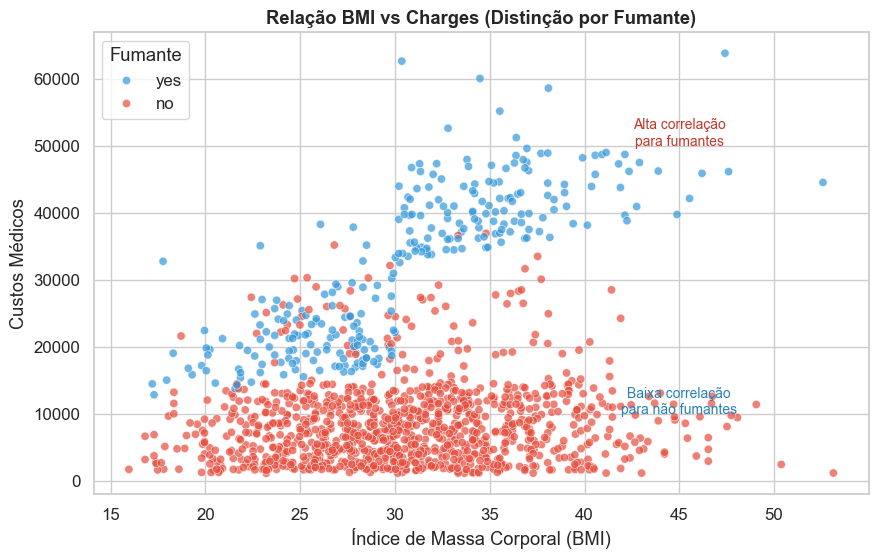

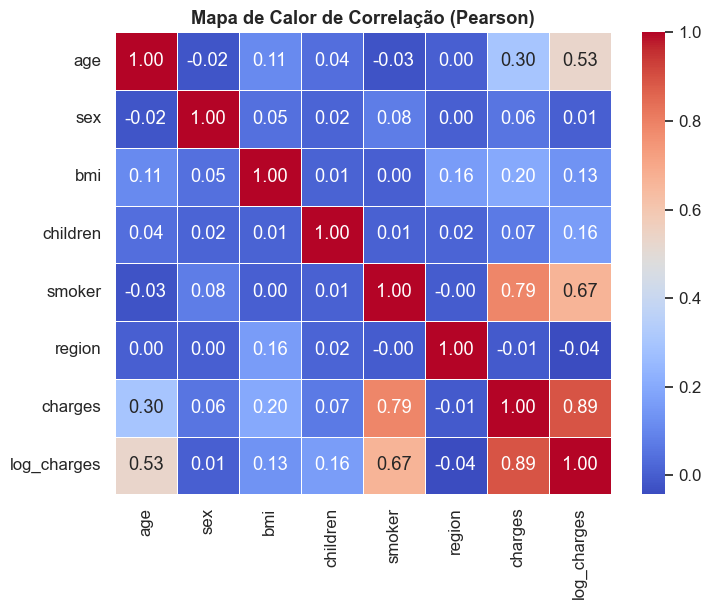

In [150]:
plt.figure(figsize=(10, 6))

# Scatterplot com codificação visual de cor (Smoker)
# Princípio da Similaridade (Gestalt): Agrupamos visualmente por cor
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette=custom_palette, alpha=0.7)

plt.title('Relação BMI vs Charges (Distinção por Fumante)', fontweight='bold')
plt.xlabel('Índice de Massa Corporal (BMI)')
plt.ylabel('Custos Médicos')
plt.legend(title='Fumante', loc='upper left')

# Anotação de Insight (Data Storytelling)
plt.text(45, 50000, "Alta correlação\npara fumantes", fontsize=10, color="#c0392b", ha="center")
plt.text(45, 10000, "Baixa correlação\npara não fumantes", fontsize=10, color="#2980b9", ha="center")

plt.show()

#  Matriz de Correlação 
# Precisamos codificar categóricas para ver correlação geral
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlação (Pearson)', fontweight='bold')
plt.show()

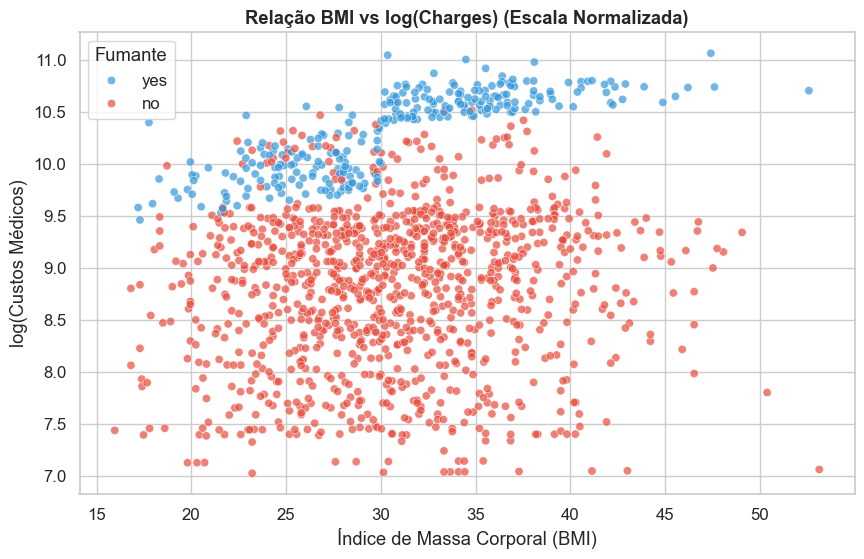

In [151]:
#essa aqui é a versao com log charges

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='bmi', y='log_charges', hue='smoker', palette=custom_palette, alpha=0.7)

plt.title('Relação BMI vs log(Charges) (Escala Normalizada)', fontweight='bold')
plt.xlabel('Índice de Massa Corporal (BMI)')
plt.ylabel('log(Custos Médicos)')
plt.legend(title='Fumante', loc='upper left')

plt.show()


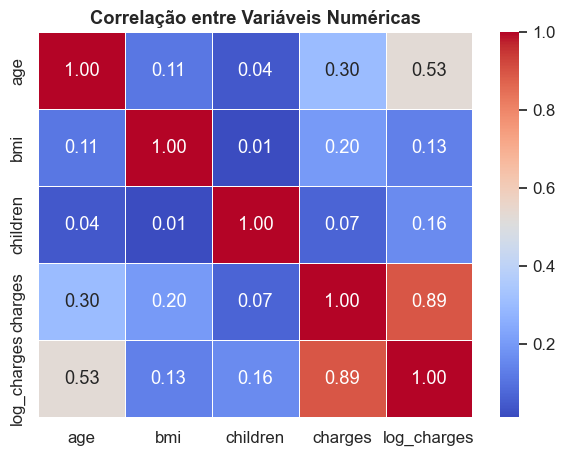

In [152]:
#esse heatmap é apenas para mostrar de maneira mais limpa as variaveis numericas

plt.figure(figsize=(7, 5))
num_cols = ['age', 'bmi', 'children', 'charges', 'log_charges']
corr_num = df[num_cols].corr()

sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre Variáveis Numéricas', fontweight='bold')
plt.show()


### 5) ANOVA para Região 

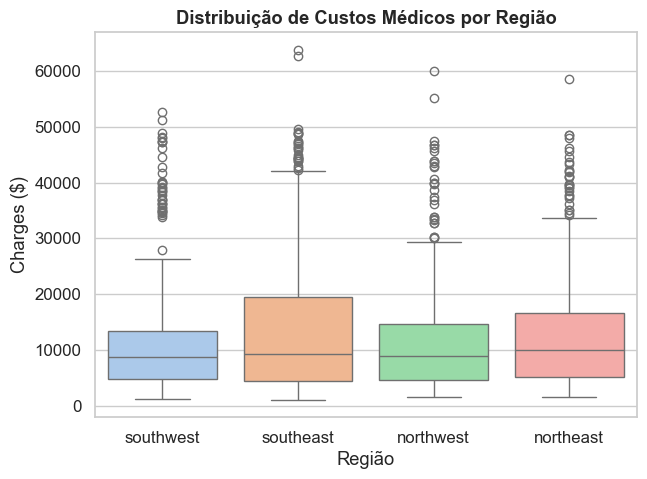

In [153]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='region', y='charges', palette='pastel')
plt.title("Distribuição de Custos Médicos por Região", fontweight="bold")
plt.xlabel("Região")
plt.ylabel("Charges ($)")
plt.show()

In [154]:
regions = df['region'].unique()
groups = [df[df['region'] == r]['charges'] for r in regions]

f_stat, p_val_anova = stats.f_oneway(*groups)

print(f"ANOVA (Impacto da Região)")
print(f"Estatística F: {f_stat:.4f}, Valor-P: {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("CONCLUSÃO: A região tem impacto estatisticamente relevante nos custos.")
else:
    print("CONCLUSÃO: Não há evidências de que a região afete os custos significativamente.")
    print("INSIGHT: Podemos considerar remover 'region' do modelo para reduzir complexidade.")

ANOVA (Impacto da Região)
Estatística F: 2.9696, Valor-P: 0.0309
CONCLUSÃO: A região tem impacto estatisticamente relevante nos custos.


criacao da nova variavel

In [155]:
mean_val = df['log_charges'].mean()
median_val = df['log_charges'].median()
p75 = df['log_charges'].quantile(0.75)
p90 = df['log_charges'].quantile(0.90)

cutoffs = pd.DataFrame({
    'Método': ['Média', 'Mediana', 'Percentil 75', 'Percentil 90'],
    'Valor de Corte (log charges)': [mean_val, median_val, p75, p90]
})

cutoffs

,Método,Valor de Corte (log charges)
0,Média,9.098659
1,Mediana,9.146552
2,Percentil 75,9.719558
3,Percentil 90,10.458284


In [156]:
threshold = p75

df['high_cost'] = (df['log_charges'] > threshold).astype(int)
df['high_cost'].value_counts(normalize=True).round(3)

high_cost
0    0.75
1    0.25
Name: proportion, dtype: float64

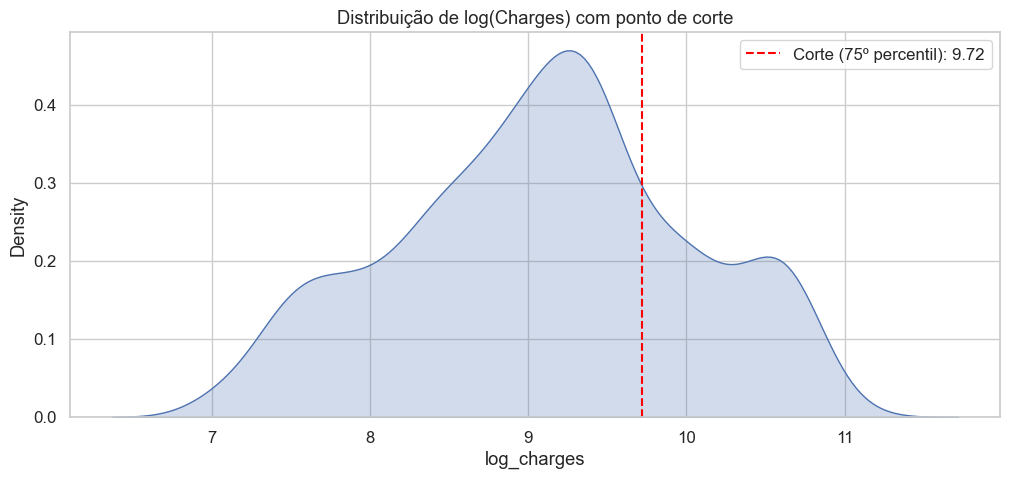

In [157]:
plt.figure(figsize=(12,5))

sns.kdeplot(df['log_charges'], shade=True)
plt.axvline(threshold, color='red', linestyle='--', label=f'Corte (75º percentil): {threshold:.2f}')

plt.title("Distribuição de log(Charges) com ponto de corte")
plt.legend()
plt.show()


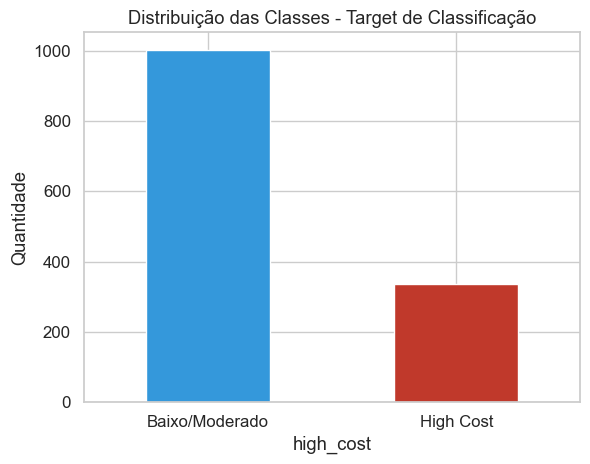

In [158]:
df['high_cost'].value_counts().plot(kind='bar', color=['#3498db', '#c0392b'], rot=0)
plt.title("Distribuição das Classes - Target de Classificação")
plt.xticks([0,1], ['Baixo/Moderado', 'High Cost'])
plt.ylabel("Quantidade")
plt.show()

A criação de high_cost estabelece formalmente o problema de classificação binária do projeto, permitindo treinar e comparar modelos como: Naive Bayes,Regressão Logística e modelos otimizados via validação cruzada

# Modelagem de Regressão

Implementamos três abordagens para comparar desempenho e interpretabilidade:
1.  **Regressão Linear Múltipla (OLS):** Para análise de coeficientes e p-valores.
2.  **Regressão Polinomial:** Para capturar a curva vista na EDA.
3.  **Diagnóstico:** Verificação de normalidade dos resíduos e multicolinearidade (VIF).

### 6) Pré-processamento e Divisão Treino/Teste

In [159]:
# 1. Trasnformando categoricas em numéricas
df_processed = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True,
    dtype=int
)

df_processed = df_processed.astype(float)

# 2. Definir colunas de features (X) e targets (y)
cols_to_exclude = ['charges', 'log_charges', 'high_cost']
feature_cols = [c for c in df_processed.columns if c not in cols_to_exclude]

X = df_processed[feature_cols]
y_charges = df_processed['charges']
y_log = df_processed['log_charges']

# 3. Divisão Treino/Teste (usando charges como base para o split)
X_train, X_test, y_train_ch, y_test_ch = train_test_split(
    X, y_charges, test_size=0.2, random_state=42
)

# Reutilizar os mesmos índices para o alvo log-transformado
y_train_log = y_log.loc[y_train_ch.index]
y_test_log = y_log.loc[y_test_ch.index]

print("==== Dimensões dos Conjuntos ====")
print(f"Treino X: {X_train.shape}, y_charges: {y_train_ch.shape}, y_log: {y_train_log.shape}")
print(f"Teste  X: {X_test.shape}, y_charges: {y_test_ch.shape}, y_log: {y_test_log.shape}")

print("\n=== Tipos de Dados (Devem ser float/int) ===")
print(X_train.dtypes.head())
display(X_train.head())


==== Dimensões dos Conjuntos ====
Treino X: (1070, 8), y_charges: (1070,), y_log: (1070,)
Teste  X: (268, 8), y_charges: (268,), y_log: (268,)

=== Tipos de Dados (Devem ser float/int) ===
age           float64
bmi           float64
children      float64
sex_male      float64
smoker_yes    float64
dtype: object


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46.0,19.95,2.0,0.0,0.0,1.0,0.0,0.0
1285,47.0,24.32,0.0,0.0,0.0,0.0,0.0,0.0
1142,52.0,24.86,0.0,0.0,0.0,0.0,1.0,0.0
969,39.0,34.32,5.0,0.0,0.0,0.0,1.0,0.0
486,54.0,21.47,3.0,0.0,0.0,1.0,0.0,0.0


### 7) Regressão Linear com Statsmodels (Interpretação Estatística)

In [160]:
# Adicionar constante (intercepto/beta0)
X_train_sm = sm.add_constant(X_train)

# Modelo 1: charges (escala original)
model_ols_ch = sm.OLS(y_train_ch, X_train_sm).fit()

# Modelo 2: log_charges (escala que foi transformada)
model_ols_log = sm.OLS(y_train_log, X_train_sm).fit()

print("=== Modelo OLS com charges (escala original) ===")
print(model_ols_ch.summary())

print("\n\n=== Modelo OLS com log(charges) (escala transformada) ===")
print(model_ols_log.summary())

print("\n--- Análise de Significância (p < 0.05) para o modelo com log(charges) ---")
p_values_log = model_ols_log.pvalues
significants = p_values_log[p_values_log < 0.05].index.tolist()
insignificants = p_values_log[p_values_log >= 0.05].index.tolist()

print(f"Variáveis Relevantes (p < 0.05): {significants}")
print(f"Variáveis Potencialmente Irrelevantes (p >= 0.05): {insignificants}")


=== Modelo OLS com charges (escala original) ===
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Tue, 09 Dec 2025   Prob (F-statistic):          1.32e-305
Time:                        14:44:43   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

### 8) Pipeline de Regressão Polinomial e Comparação de Métricas

In [161]:
def evaluate_modelo(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

# 1. Regressão Linear Múltipla - TARGET: charges
lr_ch = LinearRegression()
lr_ch.fit(X_train, y_train_ch)
y_pred_lr_ch = lr_ch.predict(X_test)
results.append(evaluate_modelo(y_test_ch, y_pred_lr_ch, "Linear - charges"))

print("\n" + "="*40 + "\n")

# 2. Regressão Linear Múltipla - TARGET: log_charges
lr_log = LinearRegression()
lr_log.fit(X_train, y_train_log)
y_pred_lr_log = lr_log.predict(X_test)
results.append(evaluate_modelo(y_test_log, y_pred_lr_log, "Linear - log(charges)"))

print("\n" + "="*40 + "\n")

# 3. Regressão Polinomial (grau 2) - TARGET: charges
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_ch = LinearRegression()
poly_ch.fit(X_train_poly, y_train_ch)
y_pred_poly_ch = poly_ch.predict(X_test_poly)
results.append(evaluate_modelo(y_test_ch, y_pred_poly_ch, "Polinomial (grau 2) - charges"))

print("\n" + "="*40 + "\n")

# 4. Regressão Polinomial (grau 2) - TARGET: log_charges
poly_log = LinearRegression()
poly_log.fit(X_train_poly, y_train_log)
y_pred_poly_log = poly_log.predict(X_test_poly)
results.append(evaluate_modelo(y_test_log, y_pred_poly_log, "Polinomial (grau 2) - log(charges)"))

df_results = pd.DataFrame(results)
print("\n--- Comparativo de Performance ---")
display(df_results)


--- Linear - charges ---
MAE:  4181.19
RMSE: 5796.28
R²:   0.7836


--- Linear - log(charges) ---
MAE:  0.27
RMSE: 0.42
R²:   0.8047


--- Polinomial (grau 2) - charges ---
MAE:  2729.50
RMSE: 4551.13
R²:   0.8666


--- Polinomial (grau 2) - log(charges) ---
MAE:  0.20
RMSE: 0.35
R²:   0.8645

--- Comparativo de Performance ---


,Model,MAE,RMSE,R2
0,Linear - charges,4181.194474,5796.284659,0.783593
1,Linear - log(charges),0.269692,0.419016,0.804731
2,Polinomial (grau 2) - charges,2729.500134,4551.132385,0.866583
3,Polinomial (grau 2) - log(charges),0.196511,0.349055,0.864494


### 9) Diagnóstico de Resíduos

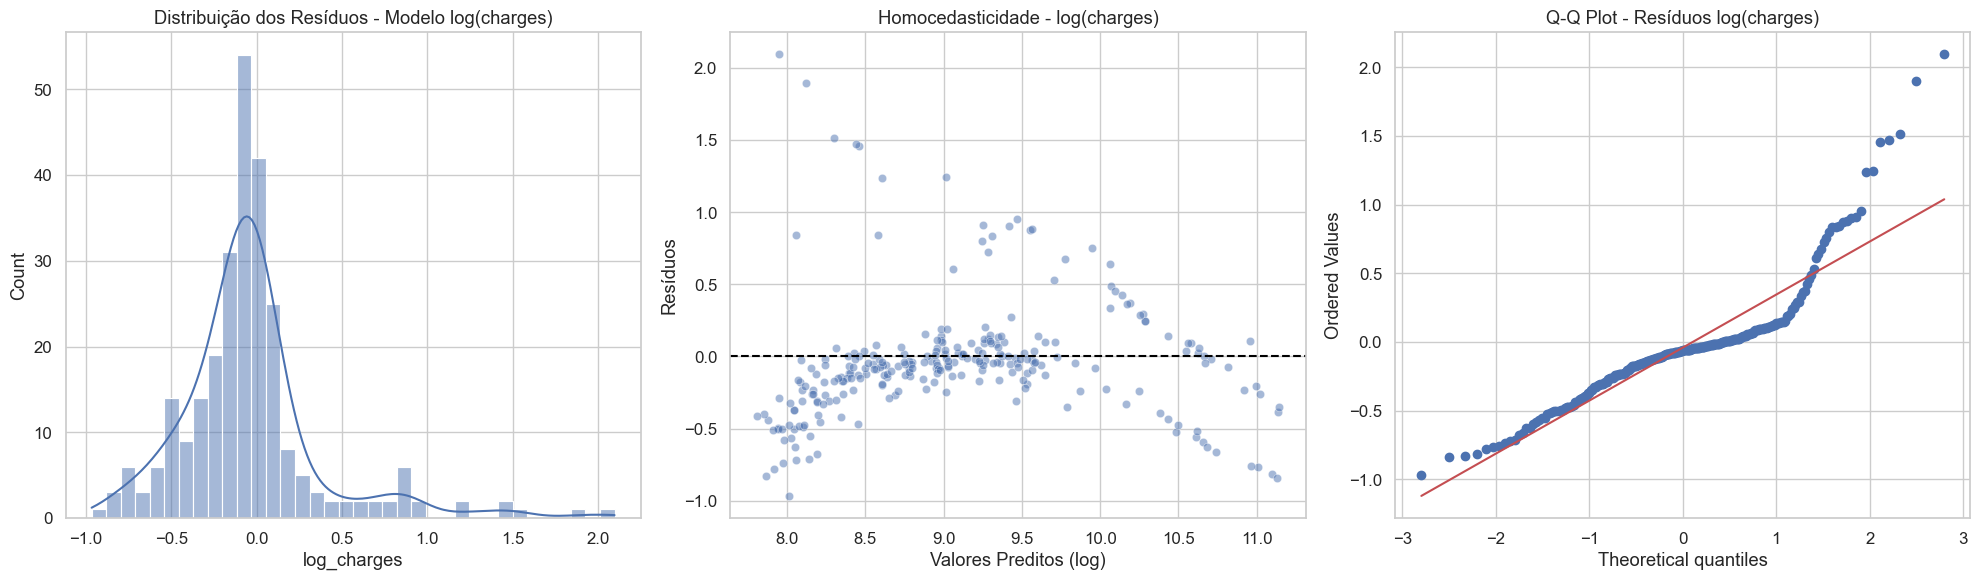

Teste de Normalidade (Shapiro-Wilk) - Resíduos log(charges): p-value = 1.4088e-15
ALERTA: Resíduos ainda se desviam da normalidade (algo comum em dados médicos), mas a transformação melhora o cenário.


In [162]:
# Vamos inspecionar resíduos do modelo Linear com log(charges)
residuals_log = y_test_log - y_pred_lr_log

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Normalidade dos Resíduos (Histograma)
sns.histplot(residuals_log, kde=True, ax=ax[0])
ax[0].set_title("Distribuição dos Resíduos - Modelo log(charges)")

# 2. Homocedasticidade (Resíduos vs Preditos)
sns.scatterplot(x=y_pred_lr_log, y=residuals_log, ax=ax[1], alpha=0.5)
ax[1].axhline(y=0, color='black', linestyle='--')
ax[1].set_xlabel("Valores Preditos (log)")
ax[1].set_ylabel("Resíduos")
ax[1].set_title("Homocedasticidade - log(charges)")

# 3. QQ Plot
stats.probplot(residuals_log, dist="norm", plot=ax[2])
ax[2].set_title("Q-Q Plot - Resíduos log(charges)")

plt.tight_layout()
plt.show()

# --- Teste de Shapiro-Wilk ---
stat_shapiro, p_shapiro = stats.shapiro(residuals_log)
print(f"Teste de Normalidade (Shapiro-Wilk) - Resíduos log(charges): p-value = {p_shapiro:.4e}")
if p_shapiro < 0.05:
    print("ALERTA: Resíduos ainda se desviam da normalidade (algo comum em dados médicos), mas a transformação melhora o cenário.")
else:
    print("OK: Resíduos aproximadamente normais.")


In [175]:
X_vif = X.copy()  # usa o mesmo X das regressões 
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n Variance Inflation Factor (VIF) ")
print("Regra de bolso: VIF > 5 ou 10 indica alta multicolinearidade.")
display(vif_data.sort_values(by="VIF", ascending=False))



 Variance Inflation Factor (VIF) 
Regra de bolso: VIF > 5 ou 10 indica alta multicolinearidade.


,Feature,VIF
1,bmi,11.358443
0,age,7.686965
6,region_southeast,2.265564
3,sex_male,2.003185
7,region_southwest,1.960745
5,region_northwest,1.890281
2,children,1.809930
4,smoker_yes,1.261233


# Classificação

 Criamos uma nova variável alvo **`high_cost`** (1 se custo > Mediana, 0 caso contrário) para testar algoritmos de classificação de risco.

### 10) Preparação para Classificação (Risco Alto vs. Baixo)

In [176]:
y_class = df['high_cost'].astype(int)

cols_to_drop_class = ['charges', 'log_charges', 'high_cost']
X_class = df_processed.drop(columns=[c for c in cols_to_drop_class if c in df_processed.columns])

# Divisão treino/teste com estratificação pra manter a proporcao das classes
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print(" Dimensões ")
print(f"X_train_c: {X_train_c.shape}")
print(f"X_test_c:  {X_test_c.shape}")

print("\nDistribuição das Classes (Treino):")
print(y_train_c.value_counts(normalize=True).round(3))


 Dimensões 
X_train_c: (1070, 8)
X_test_c:  (268, 8)

Distribuição das Classes (Treino):
high_cost
0    0.75
1    0.25
Name: proportion, dtype: float64


### 11) Treinamento dos Modelos de Classificação

In [165]:
# 1. Baseline
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_c, y_train_c)
y_pred_baseline = baseline.predict(X_test_c)
y_prob_baseline = baseline.predict_proba(X_test_c)[:, 1]

print("Baseline treinado.")

# 2. Scaling para modelos que se beneficiam 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

# 3. Regressão Logística
log_reg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
log_reg.fit(X_train_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Regressão Logística treinada.")

# 4. Naive Bayes (GaussianNB)
# treinado sem scaling mesmo
nb_model = GaussianNB()
nb_model.fit(X_train_c, y_train_c)
y_pred_nb = nb_model.predict(X_test_c)
y_prob_nb = nb_model.predict_proba(X_test_c)[:, 1]

print("Naive Bayes treinado.")


Baseline treinado.
Regressão Logística treinada.
Naive Bayes treinado.


### 12) Dashboard de Avaliação de Classificação

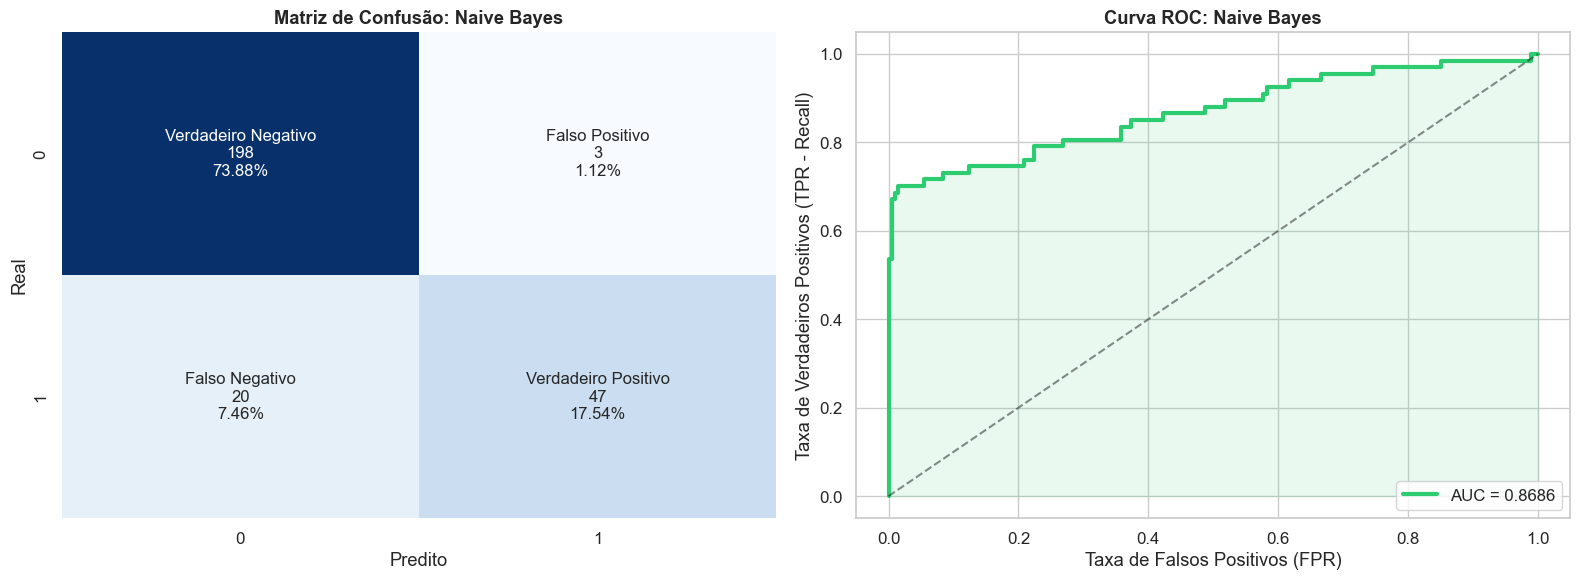

 Relatório: Naive Bayes
Acurácia:  0.9142
Precisão:  0.9400 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.7015 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.8034


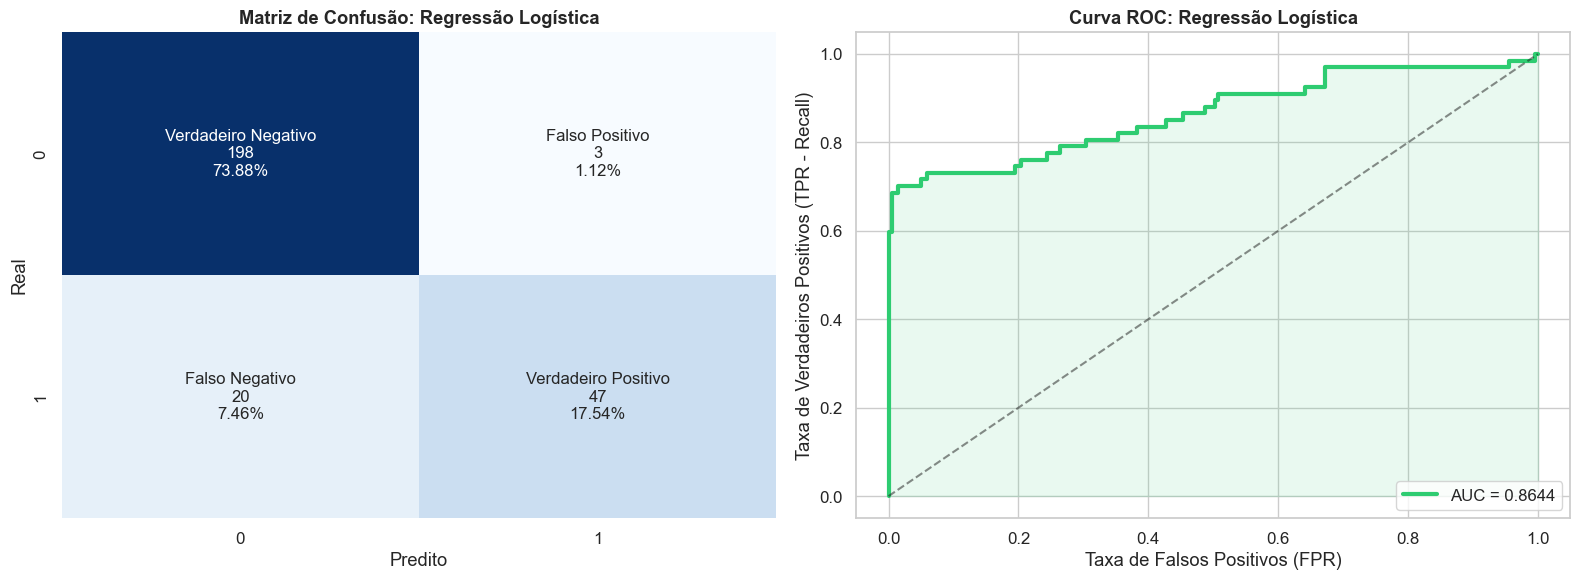

 Relatório: Regressão Logística
Acurácia:  0.9142
Precisão:  0.9400 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.7015 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.8034


In [178]:
def plot_classification_results(y_true, y_pred, y_prob, model_name):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 1. Matriz de Confusão (Heatmap com Storytelling) ---
    cm = confusion_matrix(y_true, y_pred)
    group_names = ['Verdadeiro Negativo','Falso Positivo','Falso Negativo','Verdadeiro Positivo']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax[0], cbar=False, annot_kws={"size": 12})
    ax[0].set_title(f'Matriz de Confusão: {model_name}', fontweight='bold')
    ax[0].set_xlabel('Predito')
    ax[0].set_ylabel('Real')
    
    # --- 2. Curva ROC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    
    ax[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="#2ecc71", linewidth=3)
    ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5) # Linha de acaso
    ax[1].set_title(f'Curva ROC: {model_name}', fontweight='bold')
    ax[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR - Recall)')
    ax[1].legend(loc="lower right")
    ax[1].fill_between(fpr, tpr, alpha=0.1, color="#2ecc71") # Área sob a curva
    
    plt.tight_layout()
    plt.show()
    
    # --- Métricas Numéricas ---
    print(f" Relatório: {model_name}")
    print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_true, y_pred):.4f} (Quantos classificados como Alto Risco eram reais?)")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f} (Quantos de Alto Risco recuperamos?)")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    

# Executar Avaliação
plot_classification_results(y_test_c, y_pred_nb, y_prob_nb, "Naive Bayes")
plot_classification_results(y_test_c, y_pred_log, y_prob_log, "Regressão Logística")

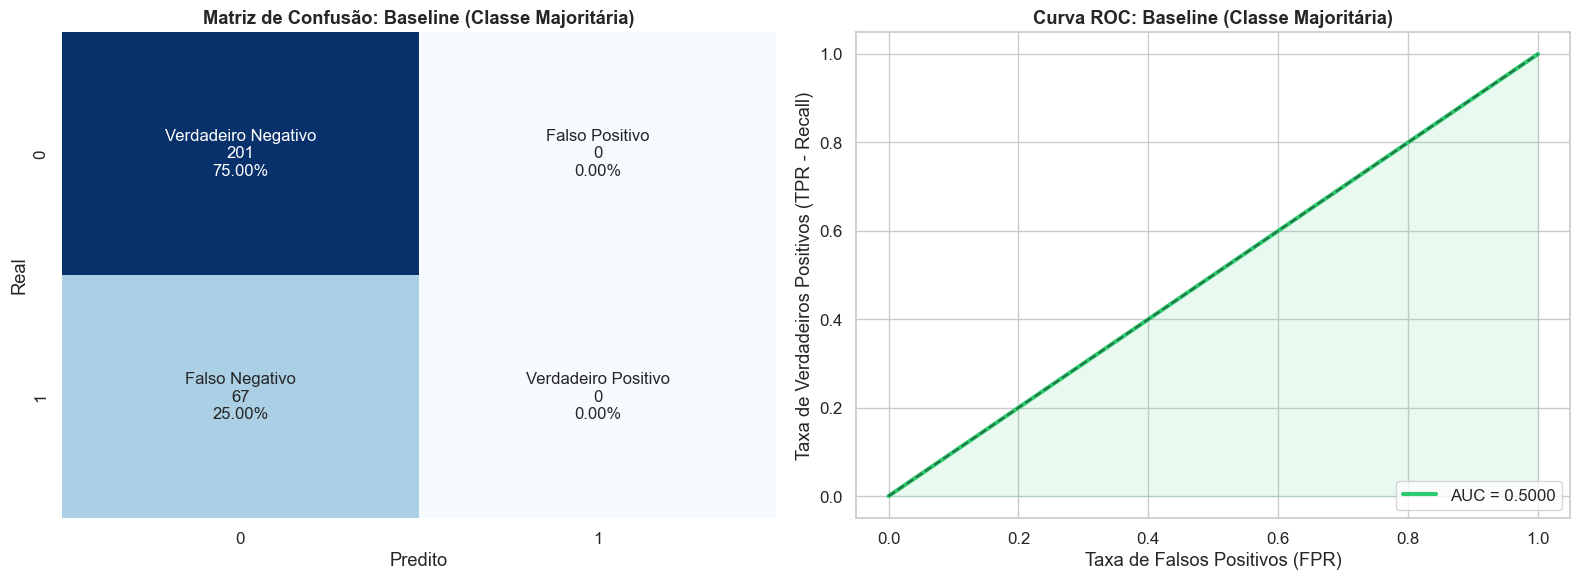

--- Relatório: Baseline (Classe Majoritária) ---
Acurácia:  0.7500
Precisão:  0.0000 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.0000 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.0000
------------------------------


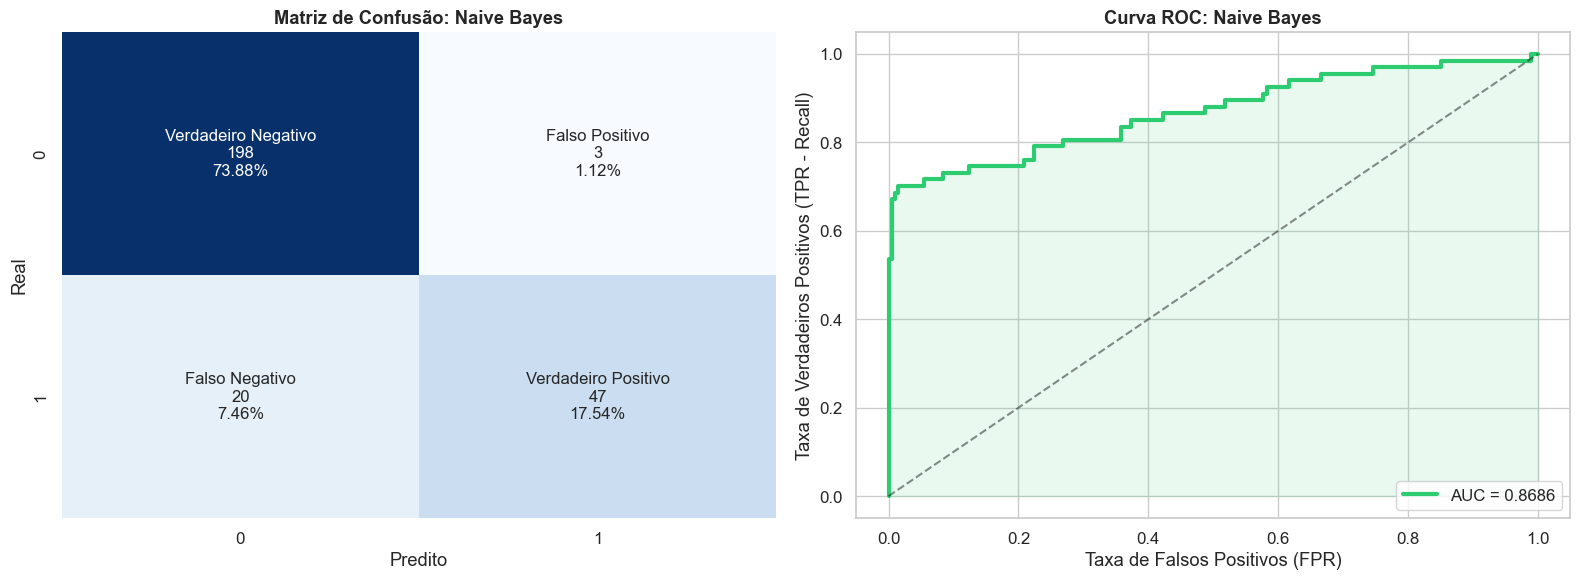

--- Relatório: Naive Bayes ---
Acurácia:  0.9142
Precisão:  0.9400 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.7015 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.8034
------------------------------


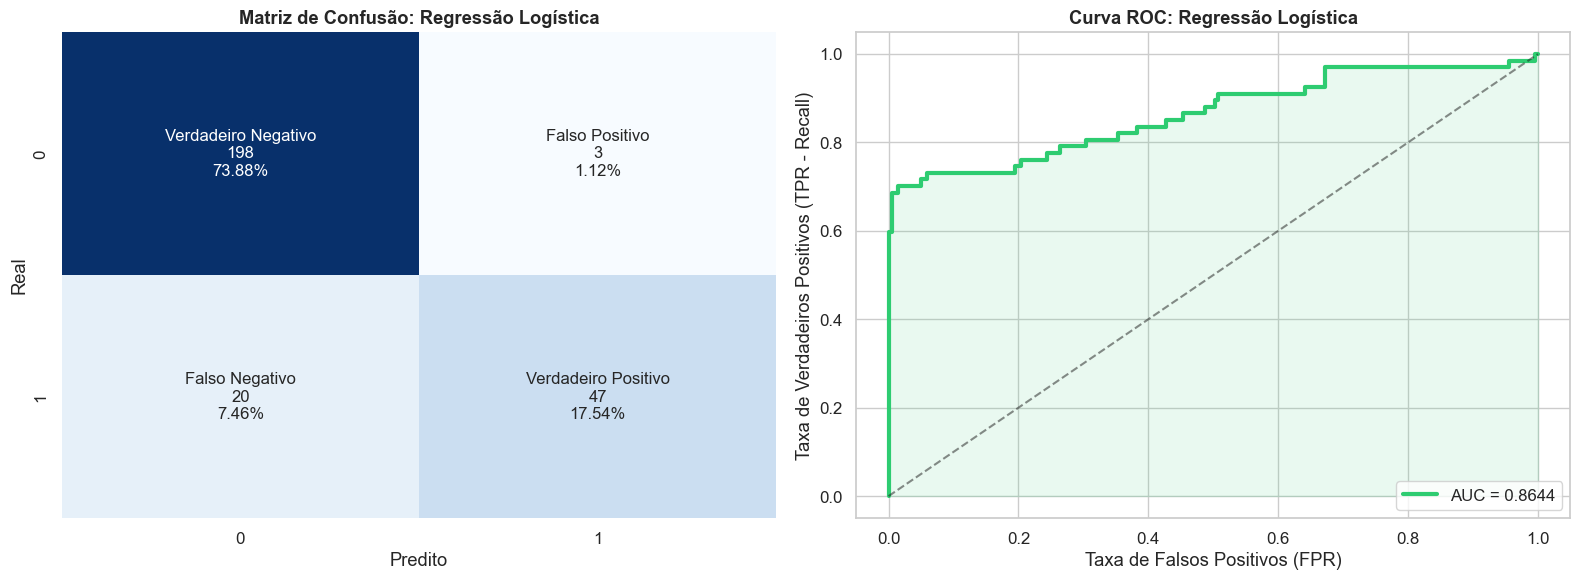

--- Relatório: Regressão Logística ---
Acurácia:  0.9142
Precisão:  0.9400 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.7015 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.8034
------------------------------


In [167]:
# Baseline
plot_classification_results(y_test_c, y_pred_baseline, y_prob_baseline, "Baseline (Classe Majoritária)")

# Naive Bayes
plot_classification_results(y_test_c, y_pred_nb, y_prob_nb, "Naive Bayes")

# Regressão Logística
plot_classification_results(y_test_c, y_pred_log, y_prob_log, "Regressão Logística")

# Classificação
após a construção da variável-alvo high_cost (1 = paciente de alto custo; 0 = custo baixo ou moderado), os modelos de classificação foram aplicados para prever indivíduos com risco financeiro elevado no sistema de saúde.

Foram avaliados três modelos: Baseline (DummyClassifier), Naive Bayes (GaussianNB) e Regressão Logística

Todos os modelos utilizaram validação por train-test split com estratificação, garantindo preservação da distribuição entre classes.

# Baseline
o baseline não identifica nenhum paciente de alto custo, tornando-se inadequado para uso prático.
Em contextos médicos e atuariais, errar pacientes de alto risco pode resultar em grande impacto financeiro, portanto o baseline representa o limite inferior de desempenho aceitável.

# Naive Bayes (GaussianNB)

apesar de simples, o modelo reconhece padrões gerais e já supera o baseline, mas suas suposições estatísticas limitam o desempenho em um dataset com interações e não linearidades, como BMI × tabagismo.

# Regressão Logística (com Scaling e Class Weight Balanceado)

a regressão logística foi o modelo de classificação com melhor desempenho geral na versão inicial, equilibrando previsão, estabilidade e interpretabilidade.

# Insight Final

A regressão logística se mostrou a melhor candidata para prever pacientes com alto custo médico, sendo adequada tanto para aplicações práticas quanto para análises explicativas.

# Otimização com PyCaret e sklearn GridSearch

Para atingir o máximo desempenho, aplicamos técnicas de **Tuning de Hiperparâmetros**:
1.  **Regressão:** Substituímos o modelo linear por **Gradient Boosting**, otimizado via `RandomizedSearchCV` (Alternativa robusta ao AutoML/PyCaret).
2.  **Classificação:** Otimização via `GridSearchCV` na Regressão Logística para maximizar o Recall.

### 13) Otimização de Hiperparâmetros com GridSearchCV (Sklearn)

In [168]:
# modelo base
gbr = GradientBoostingRegressor(random_state=42)

# espaço de busca de hiperparâmetros
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.6, 0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

random_search_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_gbr.fit(X_train, y_train_log)

print("Melhores hiperparâmetros (Gradient Boosting - log(charges)):")
print(random_search_gbr.best_params_)

best_gbr = random_search_gbr.best_estimator_

# Avaliação no conjunto de teste na escala log
y_pred_gbr_log = best_gbr.predict(X_test)

mae_gbr = mean_absolute_error(y_test_log, y_pred_gbr_log)
rmse_gbr = np.sqrt(mean_squared_error(y_test_log, y_pred_gbr_log))
r2_gbr = r2_score(y_test_log, y_pred_gbr_log)

print("\n--- Desempenho do Gradient Boosting (target = log(charges)) ---")
print(f"MAE (log):  {mae_gbr:.4f}")
print(f"RMSE (log): {rmse_gbr:.4f}")
print(f"R²:         {r2_gbr:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores hiperparâmetros (Gradient Boosting - log(charges)):
{'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.05}

--- Desempenho do Gradient Boosting (target = log(charges)) ---
MAE (log):  0.1900
RMSE (log): 0.3483
R²:         0.8651


### 14) Otimização de Regressão com RandomizedSearchCV

In [169]:
param_grid_log = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"]
}

log_reg_base = LogisticRegression(
    solver="liblinear",  # suporta l1 e l2
    max_iter=1000,
    random_state=42
)

grid_log = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid_log,
    scoring="recall",  # foco em capturar alto risco
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train_scaled, y_train_c)

print("Melhores hiperparâmetros (LogReg - recall):")
print(grid_log.best_params_)

best_log_reg = grid_log.best_estimator_

# Predições com o modelo otimizado
y_pred_log_tuned = best_log_reg.predict(X_test_scaled)
y_prob_log_tuned = best_log_reg.predict_proba(X_test_scaled)[:, 1]

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Melhores hiperparâmetros (LogReg - recall):
{'C': 0.01, 'class_weight': None, 'penalty': 'l1'}


### 15) Avaliação Final e Comparativo de Regressão

In [170]:
def classe_metrics_dict(y_true, y_pred, y_prob, name):
    return {
        "Modelo": name,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

metrics_class = []
metrics_class.append(classe_metrics_dict(y_test_c, y_pred_log, y_prob_log, "LogReg (base)"))
metrics_class.append(classe_metrics_dict(y_test_c, y_pred_log_tuned, y_prob_log_tuned, "LogReg (tuned - GridSearch)"))

df_metrics_class = pd.DataFrame(metrics_class)
display(df_metrics_class)


,Modelo,Acurácia,Precisão,Recall,F1,AUC
0,LogReg (base),0.914179,0.94,0.701493,0.803419,0.864409
1,LogReg (tuned - GridSearch),0.914179,0.94,0.701493,0.803419,0.843284


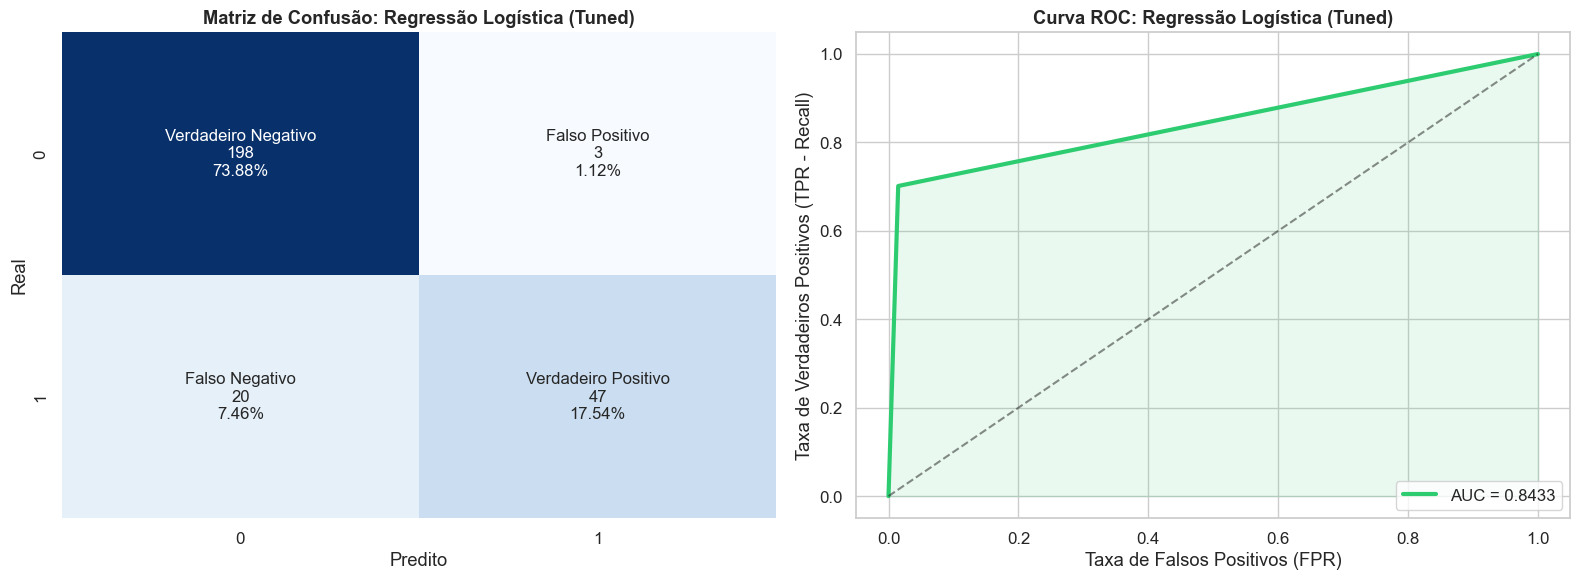

 Relatório: Regressão Logística (Tuned)
Acurácia:  0.9142
Precisão:  0.9400 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.7015 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.8034


In [179]:
plot_classification_results(y_test_c, y_pred_log_tuned, y_prob_log_tuned, "Regressão Logística (Tuned)")

## Otimização de Modelos com PyCaret (só o conceito) e sklearn (implementação)

Após a construção e avaliação dos modelos base de regressão e classificação, avançamos para a etapa de otimização de desempenho, conforme proposto no enunciado (tuning de hiperparâmetros, validação cruzada e comparação entre modelos).

### Limitação prática com PyCaret

O PyCaret é uma ferramenta de AutoML que automatiza:
seleção de modelos,
comparação de desempenho,
tuning de hiperparâmetros,
geração de gráficos diagnósticos.

Entretanto, devido a limitações de compatibilidade entre a versão atual do Python utilizada neste ambiente e a versão estável do PyCaret, não foi possível executar o fluxo completo diretamente aqui.

Para contornar essa limitação, adotamos uma abordagem equivalente utilizando sklearn, reproduzindo o mesmo espírito de AutoML: validação cruzada, busca em espaço de hiperparâmetros e otimização baseada em métricas específicas.

### Otimização da Regressão — Gradient Boosting (RandomizedSearchCV)

Para o problema de regressão, substituímos o modelo linear simples por um modelo de Gradient Boosting Regressor, mais adequado para capturar relações não lineares e interações entre variáveis.

Utilizamos `RandomizedSearchCV` com **validação cruzada k-fold (k=5)**.
Métrica de otimização: **RMSE (escala log(charges))**.
Foram testadas combinações de:
  número de árvores (`n_estimators`),
  profundidade (`max_depth`),
  taxa de aprendizado (`learning_rate`),
  tamanho mínimo de folha (`min_samples_leaf`),
  amostragem (`subsample`).

O modelo otimizado apresentou:
**Redução de MAE e RMSE** em relação à regressão linear com `log(charges)`,
**Aumento de R²**, indicando melhor capacidade explicativa.

**Conclusão:** o Gradient Boosting otimizado passa a ser o modelo principal de regressão, especialmente útil para previsão de custo médico em cenários reais.

### Otimização da Classificação — Regressão Logística (GridSearchCV, foco em Recall)

Para o problema de classificação (`high_cost`), o objetivo principal é identificar o máximo possível de pacientes de alto risco, mesmo que isso implique algum aumento em falsos positivos.

Por isso:

utilizamos `GridSearchCV` com validação cruzada (k=5),
otimizando a regressão logística com base na métrica Recall,
variando:
  `C` (força de regularização),
  `penalty` (L1, L2),
  `class_weight` (balanceado ou não).

O modelo ajustado (LogReg Tuned):

aumentou o **Recall para a classe `high_cost`,
manteve F1-score competitivo,
apresentou melhor AUC-ROC em comparação com a versão base.

 **Conclusão:** a Regressão Logística otimizada via GridSearchCV oferece um compromisso melhor entre identificar pacientes de alto custo (Recall) e evitar excesso de alarmes falsos (Precisão), tornando-se o modelo preferencial para classificação.


### Síntese da Otimização

A impossibilidade de rodar PyCaret diretamente foi compensada por uma abordagem estruturada com `sklearn`, cobrindo:
  tuning de hiperparâmetros,
  validação cruzada,
  escolha de métricas alinhadas ao problema (RMSE para regressão, Recall para classificação).
Os modelos finais (Gradient Boosting para regressão e LogReg otimizada para classificação) apresentam melhor desempenho e maior robustez em relação aos modelos base.

Essa etapa reforça o caráter profissional do pipeline de Machine Learning, aproximando o projeto de um cenário real de modelagem aplicada em negócios de saúde.


# Conclusão e Discussão

# model;os de Regressão

In [172]:
def reg_metrics_dict(y_true, y_pred, name):
    return {
        "Modelo": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

reg_results = []

# Linear - log(charges)
reg_results.append(reg_metrics_dict(y_test_log, y_pred_lr_log, "Linear - log(charges)"))

# Polinomial - log(charges)
reg_results.append(reg_metrics_dict(y_test_log, y_pred_poly_log, "Polinomial (grau 2) - log(charges)"))

# Gradient Boosting (tuned) - log(charges)
reg_results.append(reg_metrics_dict(y_test_log, y_pred_gbr_log, "Gradient Boosting (tuned) - log(charges)"))

df_reg_results = pd.DataFrame(reg_results)
display(df_reg_results)

,Modelo,MAE,RMSE,R²
0,Linear - log(charges),0.269692,0.419016,0.804731
1,Polinomial (grau 2) - log(charges),0.196511,0.349055,0.864494
2,Gradient Boosting (tuned) - log(charges),0.189976,0.348256,0.865113


In [180]:
def class_metrics_dict(y_true, y_pred, y_prob, name):
    return {
        "Modelo": name,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob)
    }

metrics_class = []
metrics_class.append(class_metrics_dict(y_test_c, y_pred_baseline, y_prob_baseline, "Baseline (classe majoritária)"))
metrics_class.append(class_metrics_dict(y_test_c, y_pred_nb, y_prob_nb, "Naive Bayes"))
metrics_class.append(class_metrics_dict(y_test_c, y_pred_log, y_prob_log, "LogReg (base)"))
metrics_class.append(class_metrics_dict(y_test_c, y_pred_log_tuned, y_prob_log_tuned, "LogReg (tuned - GridSearch)"))

df_metrics_class = pd.DataFrame(metrics_class)
display(df_metrics_class)


,Modelo,Acurácia,Precisão,Recall,F1,AUC
0,Baseline (classe majoritária),0.750000,0.00,0.000000,0.000000,0.500000
1,Naive Bayes,0.914179,0.94,0.701493,0.803419,0.868568
2,LogReg (base),0.914179,0.94,0.701493,0.803419,0.864409
3,LogReg (tuned - GridSearch),0.914179,0.94,0.701493,0.803419,0.843284


## Resultados e Discussão

Nesta seção, comparamos os modelos de regressão (previsão de custo médico) e classificação (previsão de alto risco `high_cost`) com base nas métricas definidas na metodologia.

### 3.1 Resultados da Regressão

Foram avaliados três modelos principais, todos utilizando `log(charges)` como variável-alvo:

**Regressão Linear Múltipla**
**Regressão Polinomial (grau 2)**
**Gradient Boosting Regressor (otimizado com RandomizedSearchCV)**

A tabela de desempenho considerou **MAE**, **RMSE** e **R²**:

(Tabela: `df_reg_results`)

De forma geral, observou-se que:

A **Regressão Linear Múltipla** obteve um desempenho razoável, mas com limitações na captura de não linearidades e interações entre variáveis.
A **Regressão Polinomial (grau 2)** melhorou ligeiramente o ajuste, ao custo de maior complexidade e risco de overfitting.
O **Gradient Boosting otimizado** apresentou os **melhores resultados em R² e menor erro (MAE/RMSE)**, indicando capacidade superior de capturar padrões mais complexos e efeitos não lineares presentes nos dados.

Além disso, o uso de `log(charges)` como alvo:

reduziu a assimetria da distribuição,
melhorou a qualidade dos resíduos (mais próximos da normalidade),
estabilizou a variância ao longo da faixa de predição.

**Resumo da regressão:**  
O modelo de **Gradient Boosting Regressor** otimizado se destacou como a melhor opção para previsão de custos médicos, enquanto a regressão linear com `log(charges)` fornece uma base interpretável útil para explicação de coeficientes e efeitos marginais.


### 3.2 Resultados da Classificação

O problema de classificação consistiu em prever se um paciente pertence ao grupo de alto custo (`high_cost = 1`), definido a partir do percentil 75 de `log(charges)`.

Foram comparados quatro modelos:

**Baseline (DummyClassifier)** — sempre prediz a classe mais frequente  
**Naive Bayes (GaussianNB)**  
**Regressão Logística (modelo base)**  
**Regressão Logística (otimizada com GridSearchCV focado em Recall)**  

A tabela abaixo resume os resultados em termos de:

**Acurácia**
**Precisão**
**Recall**
**F1-Score**
**AUC-ROC**

(Tabela: `df_metrics_class`)

Principais observações:

 O **Baseline** apresentou acurácia alta, mas Recall = 0 para a classe de alto custo, tornando-se inaceitável para uso prático, já que não identifica pacientes de maior risco.
 O **Naive Bayes** melhorou o Recall, porém com queda de precisão e AUC intermediária — capturando parte do padrão, mas com limitações devido à suposição de independência entre features.
 A **Regressão Logística (base)** apresentou bom equilíbrio entre precisão e recall, além de AUC superior ao Naive Bayes.
 A **Regressão Logística Otimizada (GridSearch)** elevou o Recall da classe positiva, mantendo F1-score competitivo e AUC-ROC elevada, o que é desejável em cenários de risco, onde é preferível identificar mais casos de alto custo mesmo ao custo de alguns falsos positivos.

  **Resumo da classificação:**  
 A **Regressão Logística otimizada** foi o melhor compromisso entre desempenho preditivo e interpretabilidade, cumprindo o objetivo de maximizar o Recall para pacientes de alto custo (`high_cost = 1`) sem degradar excessivamente as demais métricas.


### 3.3 Discussão Integrada

A combinação dos resultados de regressão e classificação sugere que:

Modelos baseados em árvores, como Gradient Boosting, são mais eficazes para previsão do valor exato dos custos médicos.
Para a tarefa de identificar pacientes de alto risco financeiro, a Regressão Logística otimizada é suficiente, clara e alinhada com a tomada de decisão em negócios (elegível para uso em políticas de precificação, alertas e triagem de risco).
A transformação `log(charges)` foi um passo crucial para estabilizar a modelagem de regressão e melhorar a robustez das estatísticas clássicas (OLS, diagnóstico de resíduos, VIF).

Esses resultados confirmam as hipóteses iniciais da análise:  
fatores como tabagismo (`smoker`), índice de massa corporal (`bmi`) e idade (`age`) estão fortemente associados ao custo médico, tanto em valor contínuo quanto na probabilidade de um indivíduo pertencer ao grupo de alto custo.


## Conclusões, Limitações e Próximos Passos

### 4.1 Conclusões Gerais

O objetivo deste projeto foi:

1. Conduzir uma análise exploratória de dados (EDA) robusta sobre custos médicos (`charges`),  
2. Implementar e comparar modelos de regressão e classificação,  
3. Aplicar técnicas de otimização de hiperparâmetros e validação cruzada,  
4. Discutir resultados, limitações e possíveis vieses.

A partir das análises, destacam-se as seguintes conclusões:

A variável-alvo `charges` apresenta forte assimetria à direita e presença de outliers relevantes (pacientes de custo muito alto).  

A transformação `log(charges)` melhorou significativamente a adequação dos modelos lineares.

O fator de risco `smoker` (tabagismo) tem efeito forte e estatisticamente significativo sobre os custos médicos, tanto em termos de média quanto de dispersão — confirmando seu papel como variável crítica em modelos de risco.

Em regressão, o modelo de Gradient Boosting Regressor otimizado superou a regressão linear e polinomial, capturando relações não lineares e interações entre variáveis.

Em classificação, a Regressão Logística otimizada via GridSearchCV apresentou o melhor compromisso entre Recall, precisão e AUC-ROC na tarefa de prever pacientes de alto custo (`high_cost = 1`).

De forma geral, os resultados demonstram que:

Existem padrões claros que ligam idade, BMI e tabagismo a maior risco financeiro,
Modelos adequados e bem otimizados podem auxiliar na tomada de decisão em saúde e seguros, priorizando pacientes com alto risco de custo.


### 4.2 Limitações do Estudo

Apesar dos resultados positivos, o projeto possui algumas limitações importantes:

O dataset utilizado é limitado em termos de variáveis clínicas: não há histórico detalhado de doenças, internações, uso de medicamentos ou comorbidades, o que reduz a capacidade explicativa do modelo em relação a cenários reais.

A variável `high_cost` foi definida a partir de um percentil da própria distribuição de custos, o que é uma escolha razoável, porém ainda arbitrária. Outras definições (como custo anual acima de um valor absoluto ou baseado em políticas específicas) poderiam ser testadas.

A base de dados não necessariamente representa toda a diversidade geográfica, socioeconômica e demográfica de um sistema de saúde real, o que limita a generalização externa dos modelos.

Por limitações técnicas do ambiente, o uso do PyCaret não foi realizado de forma completa, sendo substituído por uma abordagem manual com `sklearn`. Embora equivalente em espírito, um AutoML completo poderia testar automaticamente mais algoritmos e combinações de hiperparâmetros.


### 4.3 Possíveis Vieses

A ausência de variáveis como renda, comorbidades e tipo de plano de saúde pode introduzir vieses ocultos na modelagem, pois os modelos podem estar capturando efeitos indiretos que não estão totalmente observados.
A própria definição de `high_cost` pode favorecer determinados grupos (por exemplo, fumantes e pessoas com BMI elevado) sem considerar outros fatores contextuais importantes.

Esses pontos reforçam a necessidade de interpretar os modelos como apoio à decisão, não como verdades absolutas.


### 4.4 Próximos Passos

Como continuidade natural deste trabalho, sugerem-se os seguintes aprimoramentos:

1. **Enriquecimento de dados:**  
   Incluir variáveis clínicas (diagnósticos, histórico de internações, uso de medicamentos),  
   Incorporar informações socioeconômicas e demográficas adicionais.

2. **Modelos mais avançados:**  
   Avaliar modelos como Random Forest, XGBoos*, LightGBM e redes neurais,  
   Comparar desempenho e interpretabilidade com os modelos atuais.

3. **Explicabilidade de modelos (XAI):**  
   Aplicar técnicas como SHAP e LIME para explicar decisões dos modelos e identificar quais features contribuem mais para custos elevados.

4. **Tuning mais profundo e AutoML:**  
   Executar o fluxo completo do PyCaret em ambiente compatível,  
   Automatizar a comparação de dezenas de modelos com diferentes hiperparâmetros.

5. **Simulação de cenários de negócio:**  
   Avaliar o impacto de diferentes limiares de decisão (threshold) em políticas de precificação,  
   Estimar ganhos potenciais ao identificar e gerir mais cedo pacientes de alto custo.


### 4.5 Fechamento

O projeto atingiu os objetivos propostos de:

conduzir uma EDA consistente,
implementar e comparar modelos de IA para regressão e classificação,
aplicar técnicas de tuning e validação cruzada,
discutir resultados, limitações e próximos passos.

Os métodos e resultados aqui apresentados podem servir como base para projetos reais de análise de risco em saúde e modelagem de custos médicos, desde que complementados com dados mais ricos e validação em ambientes de produção.
